<a href="https://colab.research.google.com/github/ECSE415-group-3/ecse415-final-project/blob/clara%2Ffeature-based-optionA/notebooks/01_feature_based_model_optionA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update these to match where your zips are in Google Drive
TRAIN_ZIP = "/content/drive/MyDrive/ECSE415/Project/train.zip"
TEST_ZIP  = "/content/drive/MyDrive/ECSE415/Project/test.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, zipfile, warnings, csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.image as mpimg
import time

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

warnings.filterwarnings("ignore")
# HOG parameters
IMG_SIZE  = (64, 64)
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_CHANNEL_AXIS = -1    # -1 for RGB colour images

# SVM parameters
SVM_C = 10.0
SVM_KERNEL = "rbf"  # 'rbf' | 'linear' | 'poly'
SVM_GAMMA  = "scale"

# Split
TEST_SIZE = 0.20
RANDOM_STATE = 42

VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}


In [ ]:
def extract_zip(zip_path, dest):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dest)
    # Unwrap ANY number of single-folder nesting levels
    # e.g. train/train/cats -> keeps unwrapping until it finds multiple children
    root = dest
    while True:
        children = [c for c in root.iterdir() if not c.name.startswith("__") and not c.name == ".DS_Store"]
        if len(children) == 1 and children[0].is_dir():
            root = children[0]   # go one level deeper
        else:
            break
    return root

def load_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE, Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0

def compute_hog(img):
    return hog(
        img,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        channel_axis=HOG_CHANNEL_AXIS,
        feature_vector=True,
    )

In [ ]:
print("Extracting train.zip ...")
train_root = extract_zip(TRAIN_ZIP, "/content/train_data")

# Auto-detect class folders (cats, dogs)
class_dirs = sorted([d for d in train_root.iterdir() if d.is_dir()])
print(f"\nClasses found: {[d.name for d in class_dirs]}")

images, labels = [], []
for class_dir in class_dirs:
    img_paths = [p for p in class_dir.rglob("*") if p.suffix.lower() in VALID_EXT]
    print(f"  {class_dir.name}: {len(img_paths)} images")
    for p in img_paths:
        images.append(p)
        labels.append(class_dir.name)

print(f"\nTotal training images: {len(images)}")
print("Extracting HOG features ...")
X = np.array(
    [compute_hog(load_image(p)) for p in tqdm(images, unit="img")],
    dtype=np.float32
)

le = LabelEncoder()
y  = le.fit_transform(labels)
class_names = list(le.classes_) # e.g. ['cats', 'dogs']

print(f"\nFeature vector size : {X.shape[1]}")
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Extracting train.zip ...

Classes found: ['cats', 'dogs']
  cats: 10021 images
  dogs: 9979 images

Total training images: 20000
Extracting HOG features ...


100%|██████████| 20000/20000 [01:24<00:00, 236.58img/s]



Feature vector size : 1764
Label encoding: {np.str_('cats'): np.int64(0), np.str_('dogs'): np.int64(1)}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,          # keeps cat/dog balance in both splits
)
print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")

Train samples : 16000
Test  samples : 4000


In [ ]:
# Your existing pipeline setup
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(
        C=SVM_C,
        kernel=SVM_KERNEL,
        gamma=SVM_GAMMA,
        class_weight="balanced",
        decision_function_shape="ovr",
        random_state=RANDOM_STATE,
    )),
])

print("Training SVC ...")

# Start the timer
start_time = time.time()

model.fit(X_train, y_train)

# End the timer
end_time = time.time()

# Calculate duration
training_duration = (end_time - start_time)/60

print(f"Training complete in {training_duration:.2f} minutes")

Training SVC ...
Training complete in 24.82 minutes



Internal Test Accuracy: 78.83%

Classification Report:
              precision    recall  f1-score   support

        cats       0.79      0.79      0.79      2004
        dogs       0.79      0.79      0.79      1996

    accuracy                           0.79      4000
   macro avg       0.79      0.79      0.79      4000
weighted avg       0.79      0.79      0.79      4000



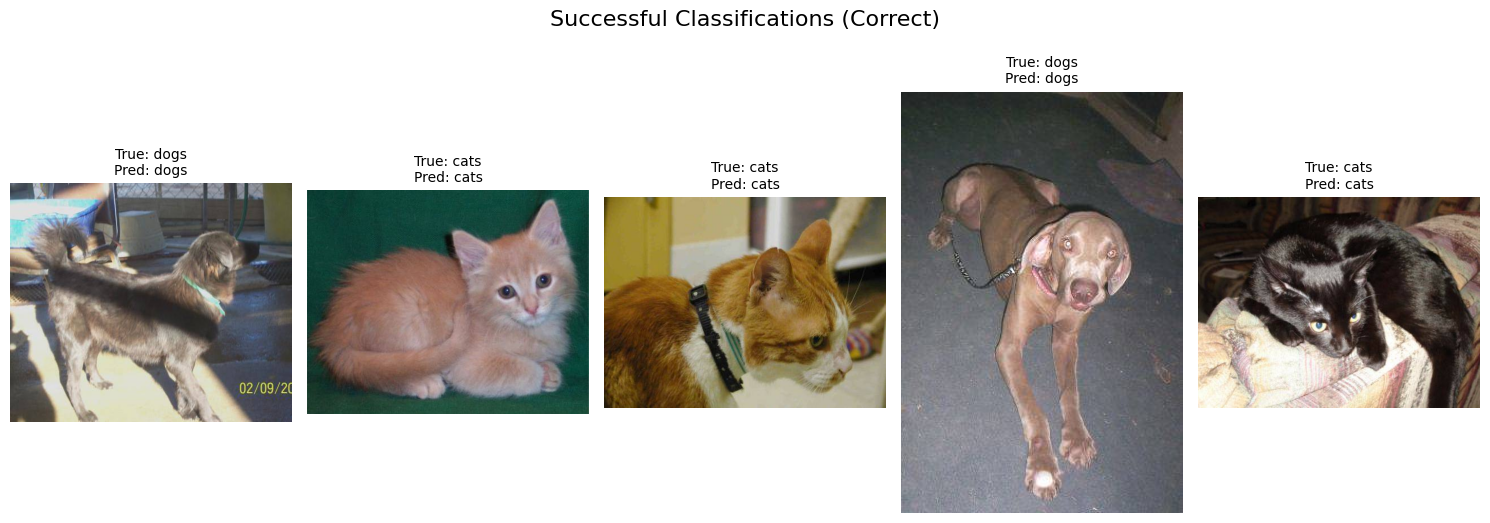

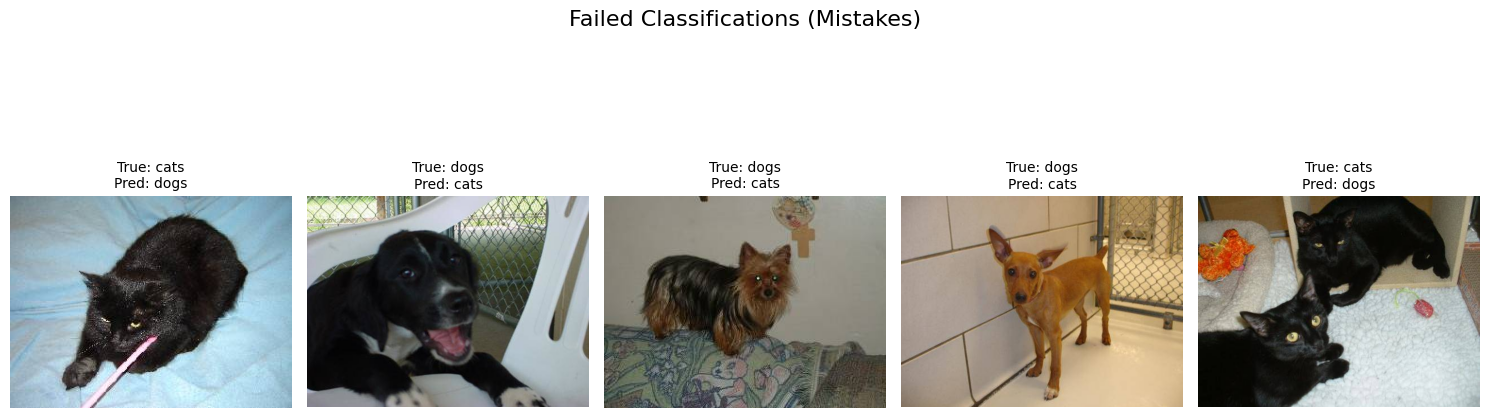

In [ ]:
def display_results(indices, title, num_samples=5):
    """Displays original high-resolution images for better clarity"""
    plt.figure(figsize=(15, 5))

    # Ensure we don't try to plot more samples than we have
    n = min(num_samples, len(indices))

    for i in range(n):
        idx = indices[i]
        plt.subplot(1, n, i + 1)

        # Get the path to the ORIGINAL file
        img_path = images[test_indices[idx]]

        # Load the original file directly (skipping the resize/grayscale step)
        # This uses the full resolution available in your folder
        img = mpimg.imread(img_path)

        plt.imshow(img)
        plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=10)
        plt.axis('off')

    plt.suptitle(title, fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()
# Get predictions
y_pred = model.predict(X_test)

# Print Metrics
acc = accuracy_score(y_test, y_pred)
print(f"\nInternal Test Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Identify Successes and Failures
# We need the original indices from the split to map back to image paths
_, test_indices = train_test_split(np.arange(len(images)), test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

# Visualize
display_results(correct_idx, "Successful Classifications (Correct)")
display_results(incorrect_idx, "Failed Classifications (Mistakes)")

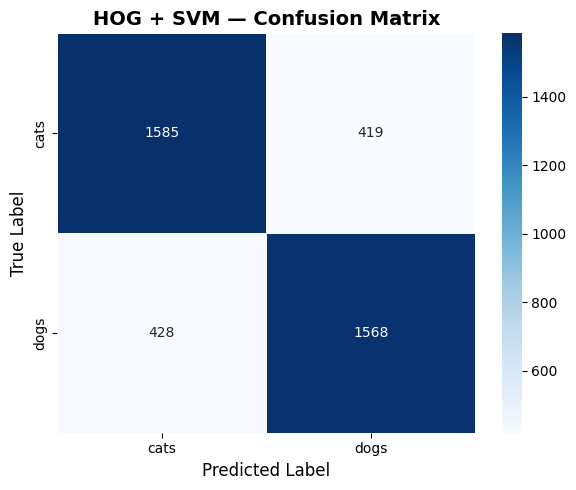

In [ ]:
#Compute and display confusion matrix for Option A
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("HOG + SVM — Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()